In [1]:
#Все необходимые библиотеки
import pandas as pd
import os
import numpy as np
import cv2
from PIL import Image
import copy

import torch
import torch.nn as nn
import torch.optim as optim
import torch as th

import torchvision
from torchvision import datasets, models
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

from skimage.io import imread
from torch.utils import data
from tqdm import tqdm

import glob
import re

import time

from sklearn.metrics import confusion_matrix
import seaborn as sns

from torchmetrics.classification import MulticlassSpecificity
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import jaccard_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import matthews_corrcoef

from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
from torch.quantization import QuantStub, DeQuantStub, prepare_qat, prepare, convert, get_default_qconfig

import timm
model_name = 'mobileone_s0'

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
original_NN = timm.create_model('mobileone_s0', pretrained=True)
original_NN

ByobNet(
  (stem): MobileOneBlock(
    (conv_kxk): ModuleList(
      (0): ConvNormAct(
        (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNormAct2d(
          48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
      )
    )
    (conv_scale): ConvNormAct(
      (conv): Conv2d(3, 48, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (bn): BatchNormAct2d(
        48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True
        (drop): Identity()
        (act): Identity()
      )
    )
    (drop_path): Identity()
    (attn): Identity()
    (act): ReLU(inplace=True)
  )
  (stages): Sequential(
    (0): Sequential(
      (0): MobileOneBlock(
        (conv_kxk): ModuleList(
          (0-3): 4 x ConvNormAct(
            (conv): Conv2d(48, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=48, bias=False)
  

In [3]:
class Multimodal_NN(nn.Module):
    def __init__(self, num_meta=3, num_classes=10, pretrained=True):
        super().__init__()
        
        self.backbone = timm.create_model(
            'mobileone_s0', pretrained=pretrained, num_classes=0
        )
        
        # Определяем размерность (в eval для безопасности BN)
        self.backbone.eval()
        with torch.no_grad():
            dummy = self.backbone(torch.randn(2, 3, 224, 224))
            cnn_dim = dummy.shape[-1]  # MobileOne после reparam всегда [B, C]
        self.backbone.train()
        
        print(f"📐 MobileOne-S0 feature dim: {cnn_dim}")
        
        self.visual_classifier = nn.Sequential(
            nn.Dropout(0.2), nn.Linear(cnn_dim, 512), nn.ReLU(inplace=True)
        )
        self.metadata_net = nn.Sequential(
            nn.Linear(num_meta, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 16), nn.ReLU()
        )
        self.combined_classifier = nn.Sequential(
            nn.Linear(512 + 16, 128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )
        
        # Флаг для отслеживания состояния репараметризации
        self._is_deployed = False

    def reparameterize_for_deployment(self):
        if hasattr(self.backbone, 'switch_to_deploy') and not self._is_deployed:
            self.backbone.switch_to_deploy()
            self._is_deployed = True
            print("⚙️  MobileOne reparameterized for deployment")

    def forward(self, img, meta):
        # 🔑 FX-SAFE: НЕТ никаких if/isinstance/dim() проверок
        # MobileOne-S0 после reparam ВСЕГДА возвращает [B, C]
        x = self.backbone(img)       # [B, 1024]
        vis = self.visual_classifier(x)
        met = self.metadata_net(meta)
        return self.combined_classifier(torch.cat([vis, met], dim=1))

In [4]:
def test_NN(model, dataset):

    model = model.to(device)
    model.eval()
    
    with torch.no_grad():

        for data in dataset:
            image, feats, label, name = data
            image, feats, label = image.to(device), feats.to(device), label.to(device)

            output = model(image, feats)

            pred = (torch.max(torch.exp(output), 1)[1]).cpu().data.numpy()

            predictions.extend(pred)

            label = label.cpu().data.numpy()
            actuals.extend(label)
            
def test_metric():
    
    cm = confusion_matrix(actuals, predictions)
    FP = np.mean(cm.sum(axis=0) - np.diag(cm))  
    FN = np.mean(cm.sum(axis=1) - np.diag(cm))
    TP = np.mean(np.diag(cm))
    TN = np.mean(cm.sum() - (FP + FN + TP))

    Sensitivity = (TP/(TP+FN))
    Specificity = (TN/(TN+FP))
    Precision = (TP/(TP+FP))
    NPV = (TN/(TN+FN))
    PPV = (TP/(TP+FP))
    FNR = (FN/(FN+TP))
    FPR = (FP/(FP+TN))

    F1 = (2*TP)/((2*TP)+FP+FN)

    print('Sensitivity: %.4f' % Sensitivity)
    print('Specificity: %.4f' % Specificity)
    print('Precision: %.4f' % Precision)
    print('NPV: %.4f' % NPV)
    print('PPV: %.4f' % PPV)
    print('FNR: %.4f' % FNR)
    print('FPR: %.4f' % FPR)
    print('F1: %.4f' % F1)


    recall_1 = recall_score(actuals, predictions, average='micro')
    print('Recall micro: %.4f' % recall_1)
    recall_2 = recall_score(actuals, predictions, average='macro')
    print('Recall macro: %.4f' % recall_2)

    precision_1 = precision_score(actuals, predictions, average='micro')
    print('Precision micro: %.4f' % precision_1)
    precision_2 = precision_score(actuals, predictions, average='macro')
    print('Precision macro: %.4f' % precision_2)


    f1_1 = f1_score(actuals, predictions, average='micro')
    print('F1 score micro: %.4f' % f1_1)
    f1_2 = f1_score(actuals, predictions, average='macro')
    print('F1 score macro: %.4f' % f1_2)
    
    jaccard_1 = jaccard_score(actuals, predictions, average='micro')
    print('Jaccard score micro: %.4f' % jaccard_1)
    jaccard_2 = jaccard_score(actuals, predictions, average='macro')
    print('Jaccard score macro: %.4f' % jaccard_2)

    accuracy_1 = accuracy_score(actuals, predictions)
    print('Accuracy score: %.4f' % accuracy_1)

    acc = accuracy_1*100

    MCC = matthews_corrcoef(actuals, predictions)
    print('Matthews corrcoef: %.4f' % MCC)

    pre = torch.tensor(predictions)
    ac = torch.tensor(actuals)

    specificity1 = MulticlassSpecificity(average='macro', num_classes=10)
    s1 = specificity1(pre, ac)
    print('Specificity macro: %.4f' % s1)

    specificity2 = MulticlassSpecificity(average='micro', num_classes=10)
    s2 = specificity2(pre, ac)
    print('Specificity micro: %.4f' % s2)

    specificity3 = MulticlassSpecificity(average='weighted', num_classes=10)
    s3 = specificity3(pre, ac)
    print('Specificity weighted: %.4f' % s3)

    specificity4 = MulticlassSpecificity(average='none', num_classes=10)
    s4 = specificity4(pre, ac)
    print('Specificity none - class vascular lesions (0): %.4f' % s4[0])
    print('Specificity none - class nevus (1): %.4f' % s4[1])
    print('Specificity none - class solar lentigo (2): %.4f' % s4[2])
    print('Specificity none - class dermatofibroma (3): %.4f' % s4[3])
    print('Specificity none - class seborrheic ketarosis (4): %.4f' % s4[4])
    print('Specificity none - class benign ketarosis (5): %.4f' % s4[5])
    print('Specificity none - class actinic keratosis (6): %.4f' % s4[6])
    print('Specificity none - class basal cell carcinoma (7): %.4f' % s4[7])
    print('Specificity none - class squamous cell carcinoma (8): %.4f' % s4[8])
    print('Specificity none - class melanoma (9): %.4f' % s4[9])

    return acc

In [5]:
#Класс для создания общего датасета с метаданными
class CombineDataset(Dataset):

    def __init__(self, frame, id_col, label_name, path_imgs, is_aug):
        
        self.frame = frame
        self.id_col = id_col
        self.label_name = label_name
        self.path_imgs = path_imgs
        self.is_aug = is_aug
        
        if self.is_aug == 1:
            self.aug = transforms.Compose([
                    transforms.Resize((img_size, img_size)),
                    transforms.RandomHorizontalFlip(p=0.3),
                    transforms.RandomRotation(degrees=10),
                    transforms.ColorJitter(brightness=0.1, contrast=0.1),
                    transforms.ToTensor(),
                    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
                    ])
        else:
            self.aug = transforms.Compose([
                    transforms.Resize((img_size, img_size)),
                    transforms.ToTensor(),
                    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
                    ])
            
            

    def __len__(self):
        return (self.frame.shape[0])

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        img_name = self.frame[self.id_col].iloc[idx]
        img = os.path.join (self.path_imgs, img_name +'.jpg')

        image1 = Image.open(img)
        image = self.aug(image1)

        feats = [feat for feat in self.frame.columns if feat not in [self.label_name,self.id_col]]
        feats  = np.array(self.frame[feats].iloc[idx])
        feats = feats.tolist()
        feats = torch.FloatTensor(feats)

        label = np.array(self.frame[self.label_name].iloc[idx])
        label = torch.tensor(label, dtype=torch.long)
        
        name = self.frame[self.id_col].iloc[idx]

        return image, feats, label, name
    
class CombineDataset_cache(Dataset):

    def __init__(self, frame, id_col, label_name, path_imgs, use_cache = False):
        
        self.frame = frame
        self.id_col = id_col
        self.label_name = label_name
        self.path_imgs = path_imgs
        self.inputs_dtype = torch.float32
        
        self.transform = transforms.Compose([
                    transforms.Resize((img_size, img_size)),
                    transforms.ToTensor(),
                    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
                    ])
        
        self.use_cache = use_cache
        
        if self.use_cache:
            self.cached_data = []

            progressbar = tqdm(range(len(self.path_imgs)), desc='Caching')
            
            for i, img in zip(progressbar, self.path_imgs):
                img = Image.open(img)
                img= self.transform(img)                
                self.cached_data.append(img)
            
    def __len__(self):
        return (self.frame.shape[0])

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()
        
        img = self.cached_data[idx]

        feats = [feat for feat in self.frame.columns if feat not in [self.label_name,self.id_col]]
        feats  = np.array(self.frame[feats].iloc[idx])
        feats = feats.tolist()
        feats = torch.FloatTensor(feats)

        label = np.array(self.frame[self.label_name].iloc[idx])
        label = torch.tensor(label, dtype=torch.long)
        
        name = self.frame[self.id_col].iloc[idx]

        return img, feats, label, name
    
    
    # Определение процессора для обучения 
def get_default_device():
    if torch.cuda.is_available():
        
        return torch.device('cuda')
    else:
        return torch.device('cpu')

In [6]:
#Класс для выведения индексов для разделения базы изображений
class Sampler(object):
    def __init__(self, data_source):
        pass
    
    def __iter__(self):
        raise NotImplementedError
        
    def __len__(self):
        raise NotImplementedError
        
class StratifiedSampler(Sampler):
    
    def __init__(self, class_vector, z):
        self.n_splits = 1
        self.class_vector = class_vector
        self.test_size = z

    def gen_sample_array(self):
        try:
            from sklearn.model_selection import StratifiedShuffleSplit
        except:
             print('Ошибка распределения изображений')
        import numpy as np
        
        s = StratifiedShuffleSplit(n_splits=self.n_splits, test_size=self.test_size)
        X = th.randn(self.class_vector.size(0),2).numpy()
        y = self.class_vector.numpy()
        s.get_n_splits(X, y)

        train_index, test_index= next(s.split(X, y))
        return train_index, test_index

    def __iter__(self):
        return iter(self.gen_sample_array())

    def __len__(self):
        return len(self.class_vector)

In [7]:
def print_model_size(mdl):
    torch.save(mdl.state_dict(), "tmp.pt")
    print("%.2f MB" %(os.path.getsize("tmp.pt")/1e6))
    os.remove('tmp.pt')


def print_model_param(model):
    for name, param in model.named_parameters():
        print(f"{name}: {param.dtype}")


def model_param_quant(model):
    for name, param in model.named_parameters():
        pr = 0
        if param.dtype == torch.float32:
            pr = param.dtype
            #print(f"Не квантован: {name}  : {param.dtype}")
        else:
            print(f"Квантован: {name} : {param.dtype}")

In [8]:
data_dir = "C:/Users/Ulyana/Мой диск (ulaliakhova@gmail.com)/Базы изображений/CLEAN DATASET/"
metadata = pd.read_csv('C:/Users/Ulyana/Мой диск (ulaliakhova@gmail.com)/Базы изображений/MetaData2.csv')

numbers = re.compile(r'(\d+)')
def numericalSort(value):
    parts = numbers.split(value)
    parts[1::2] = map(int, parts[1::2])
    return parts

data_dir2 = sorted(glob.glob('C:/Users/Ulyana/Мой диск (ulaliakhova@gmail.com)/Базы изображений/CLEAN DATASET/*.jpg'), key=numericalSort)

labels_cat = ['0. vascular lesions', '1. nevus', '2. solar lentigo', '3. dermatofibroma', '4. seborrheic ketarosis', '5. benign ketarosis', '6. actinic keratosis', '7. basal cell carcinoma', '8. squamous cell carcinoma', '9. melanoma']
labels_cat2 = ['vascular lesions', 'nevus', 'solar lentigo', 'dermatofibroma', 'seborrheic ketarosis', 'benign ketarosis', 'actinic keratosis', 'basal cell carcinoma', 'squamous cell carcinoma', 'melanoma']

img_size = 224
num_classes = 10

#CPU или GPU
device = get_default_device()

In [9]:
#Кодируем метаданные

metadata_age = metadata[['age']]
Age_grup = []

for i in metadata_age['age']:
    if i <= 44:
        Age_grup += ['young']
        #print('молодой')
    elif 45 <= i <= 59:
        Age_grup += ['middle']
        #print('средний')
    elif 60 <= i <= 74:
        Age_grup += ['elderly']
        #print('пожилой')
    elif 75 <= i:
        Age_grup += ['senile']
        #print('долгожители')
    else:
        Age_grup += ['error']
        #print('ошибка')
        
metadata['age'] = Age_grup

In [10]:
#Кодируем метаданные

encode_map_categor = {'0. vascular lesions': 0, '1. nevus': 1, '2. solar lentigo': 2, '3. dermatofibroma': 3, '4. seborrheic ketarosis': 4, '5. benign ketarosis': 5, '6. actinic keratosis': 6, '7. basal cell carcinoma': 7, '8. squamous cell carcinoma': 8, '9. melanoma': 9}

encode_map_age = {'young': 0, 'middle': 1, 'elderly': 2, 'senile': 3}
encode_map_sex = {'male': 0, 'female': 1}
encode_map_anatomloc = {'anterior torso': 0, 'head/neck': 1, 'lateral torso': 2, 'lower extremity': 3, 'oral/genital': 4, 'palms/soles': 5, 'posterior torso': 6, 'upper extremity': 7}

#encode_map_age = {'young': '0001', 'middle': '0010', 'elderly': '0100', 'senile': '1000'}
#encode_map_sex = {'male': '01', 'female': '10'}
#encode_map_anatomloc = {'anterior torso': '00000001', 'head/neck': '00000010', 'lateral torso': '00000100', 'lower extremity': '00001000', 'oral/genital': '00010000', 'palms/soles': '00100000', 'posterior torso': '01000000', 'upper extremity': '10000000'}

metadata.replace({
    'diagnosis': encode_map_categor,
    'age': encode_map_age,
    'sex': encode_map_sex,
    'anatomloc': encode_map_anatomloc}, inplace=True)

metadata = metadata.astype({
    'diagnosis': 'int32',
    'age': 'int32',
    'sex': 'int32',
    'anatomloc': 'int32'
})

metadata['diagnosis'] = np.array(metadata['diagnosis'], dtype=np.int32)
metadata['age'] = np.array(metadata['age'], dtype=np.int32)
metadata['sex'] = np.array(metadata['sex'], dtype=np.int32)
metadata['anatomloc'] = np.array(metadata['anatomloc'], dtype=np.int32)

C:\Users\Ulyana\AppData\Local\Temp\ipykernel_3688\438579890.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  metadata.replace({


In [11]:
#Определяем индексы для разделения базы изображений

test_size = 0.2
valid_size = 0.25

data_label = metadata['diagnosis'].to_numpy()

ss = StratifiedSampler(torch.FloatTensor(data_label), test_size)
pre_train_indices, test_indices = ss.gen_sample_array()

train_label = np.delete(data_label, test_indices, None)
ss = StratifiedSampler(torch.FloatTensor(train_label), valid_size)
train_indices, val_indices = ss.gen_sample_array()

indices = {'train': pre_train_indices[train_indices],
           'val': pre_train_indices[val_indices],
           'test': test_indices
           }

train_indices = indices['train']
val_indices = indices['val']
test_indices = indices['test']

#Выводим индексы для разделения базы изображений

print("Размер тренировочной базы:", len(train_indices))
print("Размер валидационной базы:", len(val_indices))
print("Размер тестовой базы:", len(test_indices))

#torch.save(train_indices, 'train_indices.pt')
#torch.save(val_indices, 'val_indices.pt')
#torch.save(test_indices, 'test_indices.pt')

train_indices = torch.load('train_indices.pt', weights_only=False)
val_indices = torch.load('val_indices.pt', weights_only=False)
test_indices = torch.load('test_indices.pt', weights_only=False)

len_valset = len(val_indices)
len_trainset = len(train_indices)

Размер тренировочной базы: 25035
Размер валидационной базы: 8345
Размер тестовой базы: 8345


In [12]:
Data_set = CombineDataset_cache(metadata, 'name', 'diagnosis', data_dir2, use_cache = True)
#Data_set_train = CombineDataset(metadata, 'name', 'diagnosis', data_dir, is_aug = 1)
#Data_set_test = CombineDataset(metadata, 'name', 'diagnosis', data_dir, is_aug = 0)

Caching: 100%|██████████████████████████████████████████████████████████████████| 41725/41725 [02:00<00:00, 345.79it/s]


In [13]:
batch_size = 64

trainloader = torch.utils.data.DataLoader(Data_set, batch_size = batch_size, shuffle = False,  sampler = train_indices)
valloader = torch.utils.data.DataLoader(Data_set, batch_size = batch_size, shuffle = False,  sampler = val_indices)
testloader = torch.utils.data.DataLoader(Data_set, batch_size = batch_size, shuffle = False,  sampler = test_indices)

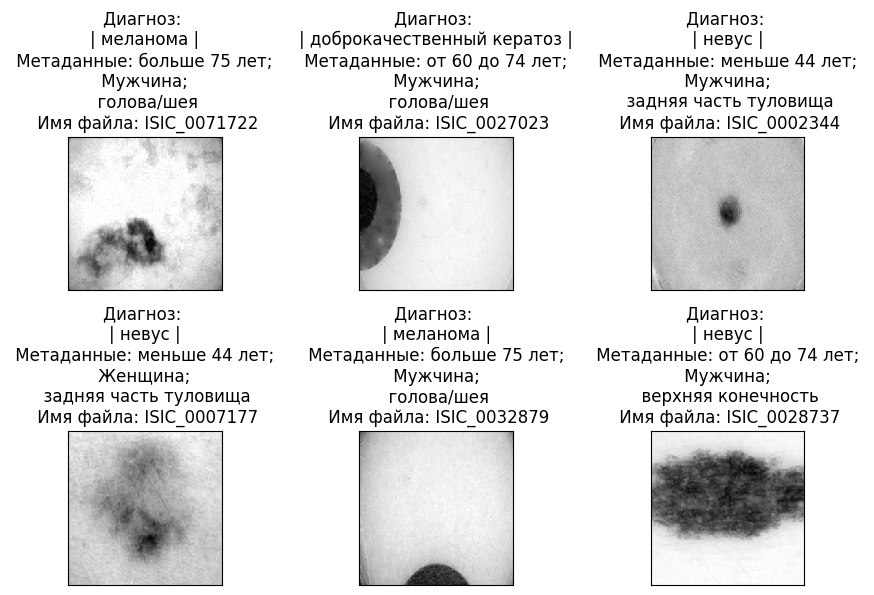

In [14]:
age = ['меньше 44 лет', 'от 45 до 59 лет', 'от 60 до 74 лет', 'больше 75 лет']
sex = ['Мужчина', 'Женщина']
anatomloc = ['торс', 'голова/шея', 'боковая часть туловища', 'нижняя конечность', 'оральная/генитальная зона', 'ладони/подошвы', 'задняя часть туловища', 'верхняя конечность']
lab = ['сосудистое поражение', 'невус', 'солнечное лентиго', 'дерматофиброма', 'себорейный кератоз', 'доброкачественный кератоз', 'актинический кератоз', 'базально-клеточная карцинома', 'плоскоклеточный рак', 'меланома']


examples = enumerate(trainloader)
batch_idx, (example_data, example_meta, example_targets, example_name) = next(examples)

plt.figure(1, figsize=[9,9])
for i in range(6):
    plt.subplot(3, 3, i+1)
    plt.tight_layout()
    plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
    age1 = example_meta[i][0].type(torch.LongTensor)
    sex1 = example_meta[i][1].type(torch.LongTensor)
    anatomloc1 = example_meta[i][2].type(torch.LongTensor)
    plt.title("Диагноз: \n| {} |\n Метаданные: {}; \n {}; \n  {} \n Имя файла: {}".format(lab[example_targets[i]], age[age1], sex[sex1], anatomloc[anatomloc1], example_name[i]))
    plt.xticks([])
    plt.yticks([])

plt.show()

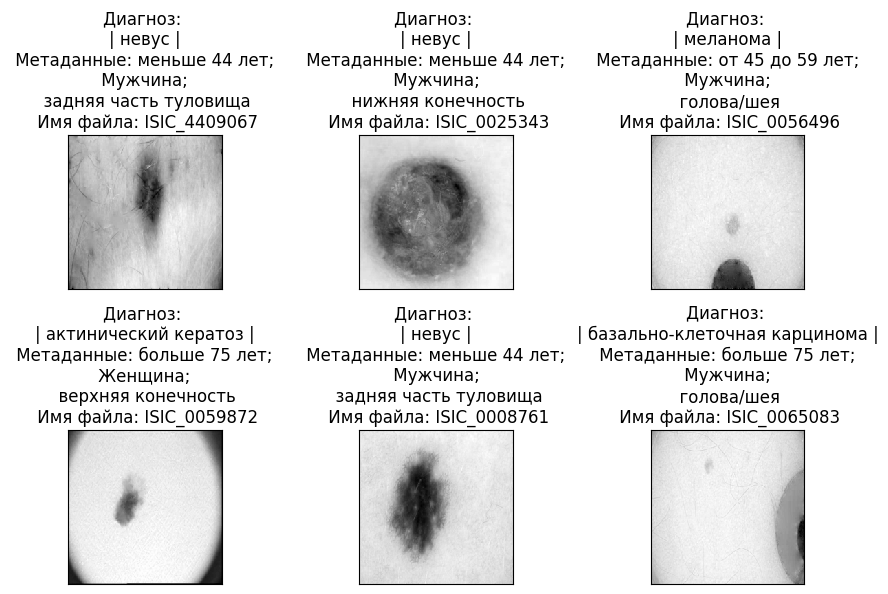

In [15]:
examples = enumerate(valloader)
batch_idx, (example_data, example_meta, example_targets, example_name) = next(examples)

plt.figure(1, figsize=[9,9])
for i in range(6):
    plt.subplot(3, 3, i+1)
    plt.tight_layout()
    plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
    age1 = example_meta[i][0].type(torch.LongTensor)
    sex1 = example_meta[i][1].type(torch.LongTensor)
    anatomloc1 = example_meta[i][2].type(torch.LongTensor)
    plt.title("Диагноз: \n| {} |\n Метаданные: {}; \n {}; \n  {} \n Имя файла: {}".format(lab[example_targets[i]], age[age1], sex[sex1], anatomloc[anatomloc1], example_name[i]))
    plt.xticks([])
    plt.yticks([])

plt.show()

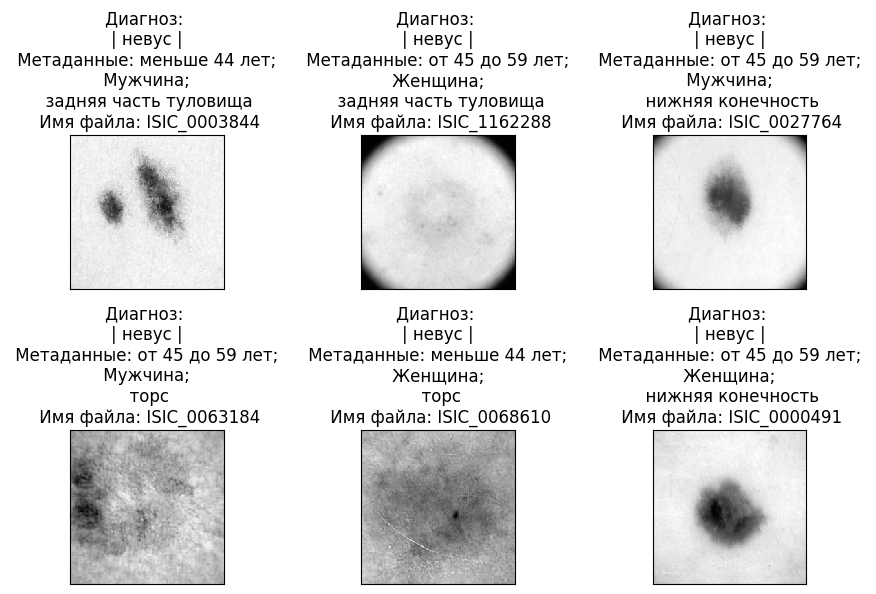

In [16]:
examples = enumerate(testloader)
batch_idx, (example_data, example_meta, example_targets, example_name) = next(examples)

plt.figure(1, figsize=[9,9])
for i in range(6):
    plt.subplot(3, 3, i+1)
    plt.tight_layout()
    plt.imshow(example_data[i][0], cmap='gray', interpolation='none')
    age1 = example_meta[i][0].type(torch.LongTensor)
    sex1 = example_meta[i][1].type(torch.LongTensor)
    anatomloc1 = example_meta[i][2].type(torch.LongTensor)
    plt.title("Диагноз: \n| {} |\n Метаданные: {}; \n {}; \n  {} \n Имя файла: {}".format(lab[example_targets[i]], age[age1], sex[sex1], anatomloc[anatomloc1], example_name[i]))
    plt.xticks([])
    plt.yticks([])

plt.show()

In [17]:
def train_and_evaluate(model, trainloader, valloader, criterion, optimizer, len_trainset, len_valset, num_epochs, name_model):

    start_time_glob = time.time()
    model = model.to(device)
    model.train()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        
        model.train()
        start_time_tarin = time.time()
        
        print('_' * 120)
        print('Эпоха {}/{}\n'.format(epoch+1, num_epochs))
        
        running_loss = 0.0
        running_corrects = 0
        train_accuracy = 0
        total = 0
        correct_train = 0
        
        for i, data in enumerate(trainloader):
            inputs, feats, labels, name = data
            inputs, feats, labels = inputs.to(device), feats.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs, feats)
            loss = criterion(outputs, labels)
            
            _, preds = torch.max(outputs, 1)
            loss.backward() 
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            correct_train += preds.eq(labels.data.view_as(preds)).sum()

            total += labels.size(0)
            train_accuracy = 100 * running_corrects / total
            train_accuracy = train_accuracy.cpu()

            if i % 100 == 0:
                print('Тренировочная эпоха: {} [{}/{} ({:.0f}%)]\t\t | Ошибка: {:.4f}\t | Точность распознавания: {:.2f}%'.format(epoch+1, batch_size * i, len_trainset, 100 * i / len(trainloader), loss.item(), train_accuracy))
                
                train_counter.append((i*batch_size) + ((epoch)*len_trainset))
                train_losses.append(loss.item())
                train_acc.append(train_accuracy)
                
        epoch_loss = running_loss / len_trainset
        epoch_acc = running_corrects.double() / len_trainset
        
        time_tarin = time.time()-start_time_tarin
        
        print('\n   Тренировочная ошибка: {:.4f} Точность: {}/{} ({:.2f}%)'.format(epoch_loss, correct_train, len_trainset, 100 * epoch_acc))
        print ('        Время обучения: {}\n'.format(time.strftime("%H:%M:%S", time.gmtime(time_tarin))))
      
        model = model.to(device)
        model.eval()
        start_time_test = time.time()
        
        running_loss_val = 0.0 
        running_corrects_val = 0
        correct = 0
        
        with torch.no_grad():
            
            for data in valloader:
                
                inputs, feats, labels, name = data
                inputs, feats, labels = inputs.to(device), feats.to(device), labels.to(device)
            
                outputs = model(inputs, feats)
            
                loss = criterion(outputs,labels)
                _, preds = torch.max(outputs, 1)

                correct += preds.eq(labels.data.view_as(preds)).sum()
            
                running_loss_val += loss.item() * inputs.size(0)
                running_corrects_val += torch.sum(preds == labels.data)
        
            epoch_loss_val = running_loss_val / len_valset
            epoch_acc_val = running_corrects_val.double() / len_valset
            epoch_acc_val_2 = 100 * epoch_acc_val.cpu()

            test_losses.append(epoch_loss_val)
            test_acc.append(epoch_acc_val_2)

            time_test = time.time()-start_time_test
        
            if epoch_acc_val > best_acc:
                best_acc = epoch_acc_val
                best_model_wts = copy.deepcopy(model.state_dict())
            
                torch.save(model.state_dict(), f"BestModel_{model_name}_{name_model}.pth")

            scheduler.step(best_acc)

            print('   Валидационная ошибка: {:.4f} Точность: {}/{} ({:.2f}%)'.format(epoch_loss_val, correct, len_valset, 100 * epoch_acc_val))
            print ('        Время тестирования: {}\n'.format(time.strftime("%H:%M:%S", time.gmtime(time_test))))
        
            print('Лучшая валидационная точность: {:.4f}'.format(best_acc))

            #torch.save(model.state_dict(), f"{name_model}_epoch-{epoch+1}.pth")
            
            #model.load_state_dict(best_model_wts)

    time_glob = time.time()-start_time_glob
    print('_' * 120)
    print ('\nОбщее время обучения: {}'.format(time.strftime("%H:%M:%S", time.gmtime(time_glob))))
    
    return model

In [20]:
num_metadata_features = 3
num_classes = 10

fp32_model = Multimodal_NN(num_metadata_features, num_classes)
device = get_default_device()


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(fp32_model.parameters(), lr=0.001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.1, patience = 5)

num_epochs = 20

train_losses = []
train_counter = []
train_acc = []

test_losses = []
test_counter = [i*len_trainset for i in range(num_epochs)]
test_acc = []

fp32_model = train_and_evaluate(fp32_model, trainloader, valloader, criterion, optimizer, len_trainset, len_valset, num_epochs, 'fp32_model')

________________________________________________________________________________________________________________________
Эпоха 1/20

Тренировочная эпоха: 1 [0/25035 (0%)]		 | Ошибка: 2.3441	 | Точность распознавания: 7.81%
Тренировочная эпоха: 1 [6400/25035 (26%)]		 | Ошибка: 0.9448	 | Точность распознавания: 56.68%
Тренировочная эпоха: 1 [12800/25035 (51%)]		 | Ошибка: 0.9616	 | Точность распознавания: 61.49%
Тренировочная эпоха: 1 [19200/25035 (77%)]		 | Ошибка: 1.0392	 | Точность распознавания: 63.43%

   Тренировочная ошибка: 1.1543 Точность: 16143/25035 (64.48%)
        Время обучения: 00:00:29

   Валидационная ошибка: 0.8873 Точность: 6314/8345 (75.66%)
        Время тестирования: 00:00:05

Лучшая валидационная точность: 0.7566
________________________________________________________________________________________________________________________
Эпоха 2/20

Тренировочная эпоха: 2 [0/25035 (0%)]		 | Ошибка: 0.8863	 | Точность распознавания: 75.00%
Тренировочная эпоха: 2 [6400/25

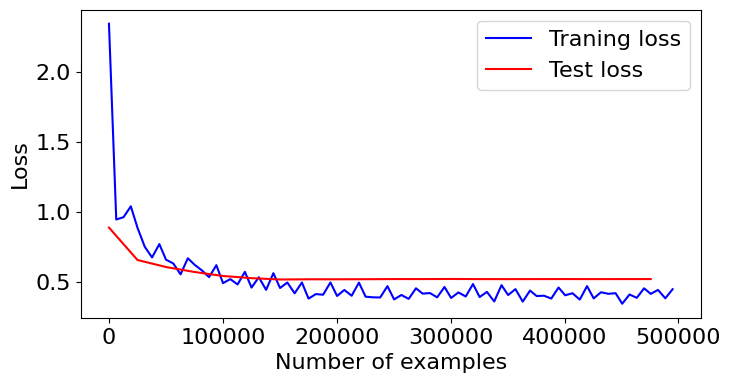

<Figure size 640x480 with 0 Axes>

In [21]:
plt.figure(figsize=(8, 4))
plt.rcParams['font.size'] = '16'
plt.plot(train_counter, train_losses, color='blue')
plt.plot(test_counter, test_losses, color='red')
plt.legend(['Traning loss', 'Test loss'], loc='upper right')
plt.xlabel('Number of examples')
plt.ylabel('Loss')
fig = plt.figure()
plt.show()

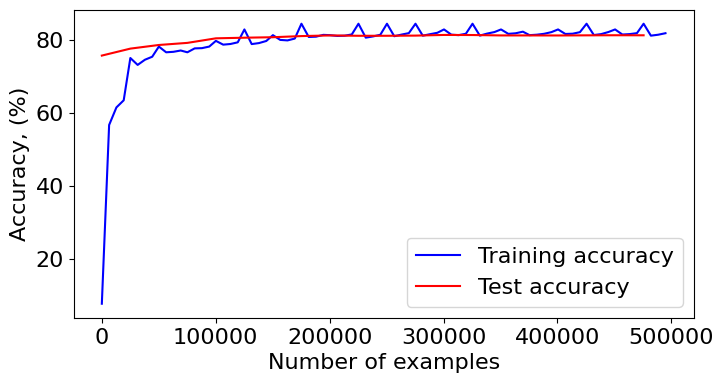

<Figure size 640x480 with 0 Axes>

In [22]:
plt.figure(figsize=(8, 4))
plt.rcParams['font.size'] = '16'
plt.plot(train_counter, train_acc, color='blue')
plt.plot(test_counter, test_acc, color='red')
plt.legend(['Training accuracy', 'Test accuracy'], loc='lower right')
plt.xlabel('Number of examples')
plt.ylabel('Accuracy, (%)')
fig = plt.figure()
plt.show()

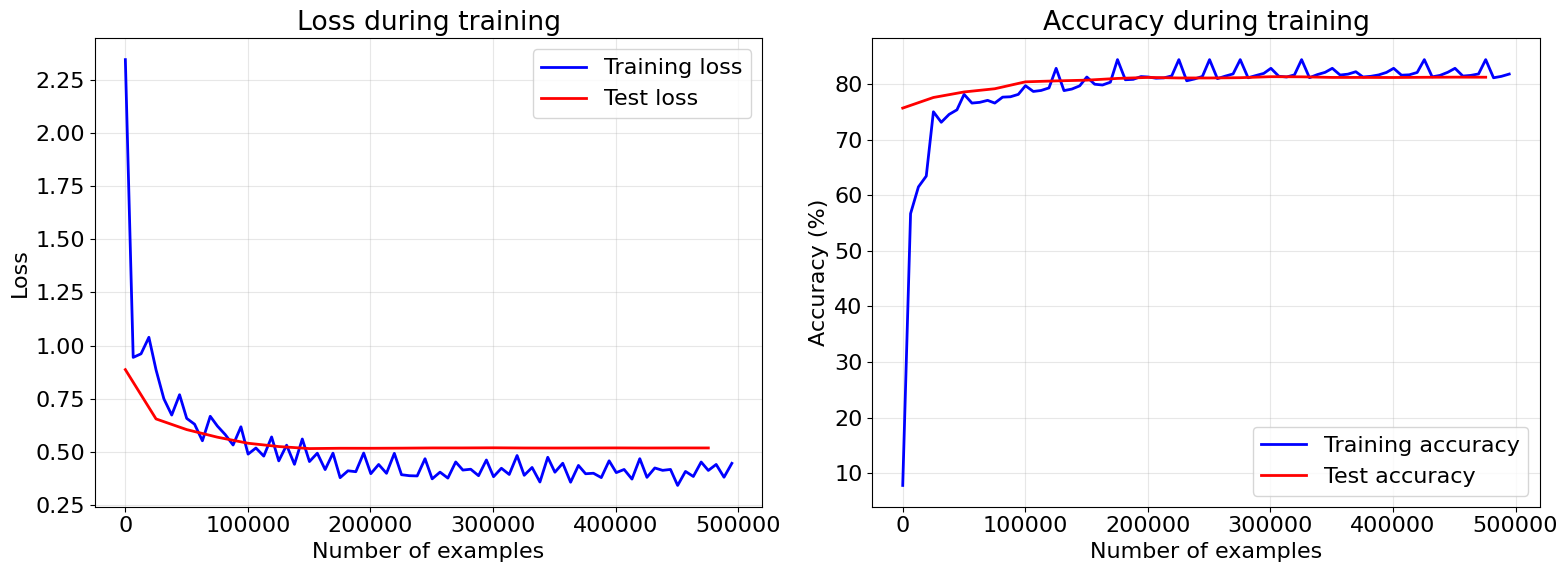

In [23]:
plt.figure(figsize=(16, 6))
plt.rcParams['font.size'] = '16'

# Первый график - Loss
plt.subplot(1, 2, 1)  # 1 строка, 2 столбца, 1-й график
plt.plot(train_counter, train_losses, color='blue', linewidth=2)
plt.plot(test_counter, test_losses, color='red', linewidth=2)
plt.legend(['Training loss', 'Test loss'], loc='upper right')
plt.xlabel('Number of examples')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.grid(True, alpha=0.3)

# Второй график - Accuracy
plt.subplot(1, 2, 2)  # 1 строка, 2 столбца, 2-й график
plt.plot(train_counter, train_acc, color='blue', linewidth=2)
plt.plot(test_counter, test_acc, color='red', linewidth=2)
plt.legend(['Training accuracy', 'Test accuracy'], loc='lower right')
plt.xlabel('Number of examples')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy during training')
plt.grid(True, alpha=0.3)

plt.tight_layout()  # Чтобы графики не перекрывались
plt.show()

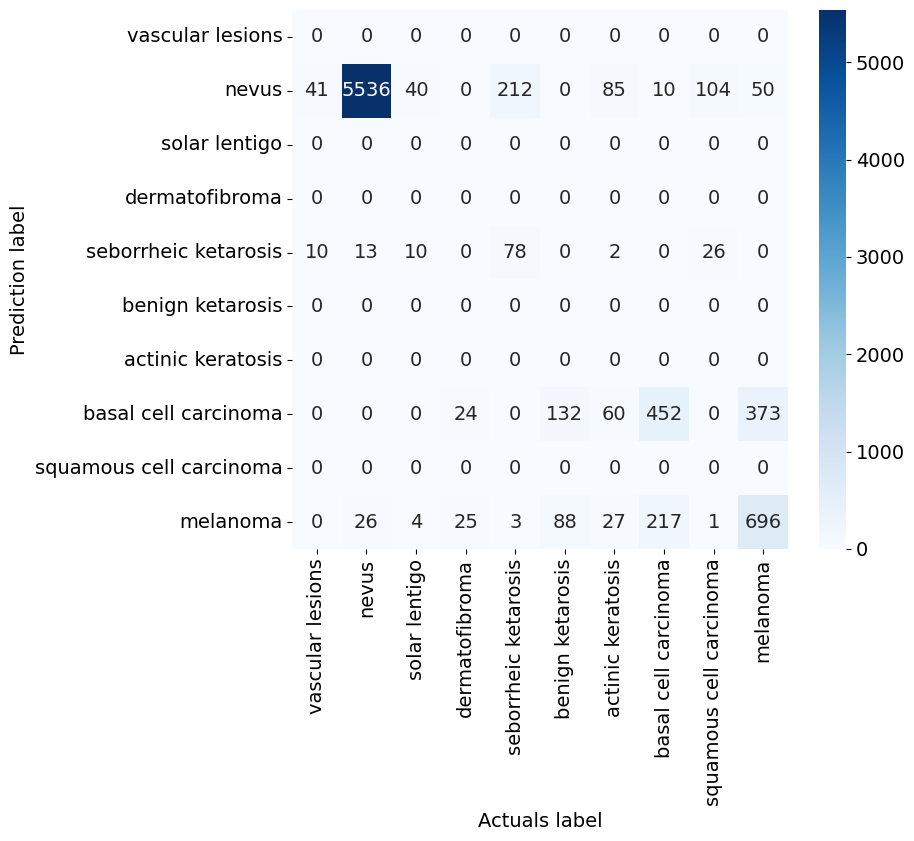

Sensitivity: 0.8103
Specificity: 0.9789
Precision: 0.8103
NPV: 0.9789
PPV: 0.8103
FNR: 0.1897
FPR: 0.0211
F1: 0.8103
Recall micro: 0.8103
Recall macro: 0.2547
Precision micro: 0.8103
Precision macro: 0.2546
F1 score micro: 0.8103
F1 score macro: 0.2468
Jaccard score micro: 0.6811
Jaccard score macro: 0.1943
Accuracy score: 0.8103
Matthews corrcoef: 0.6164
Specificity macro: 0.9666
Specificity micro: 0.9789
Specificity weighted: 0.8555
Specificity none - class vascular lesions (0): 1.0000
Specificity none - class nevus (1): 0.8043
Specificity none - class solar lentigo (2): 1.0000
Specificity none - class dermatofibroma (3): 1.0000
Specificity none - class seborrheic ketarosis (4): 0.9924
Specificity none - class benign ketarosis (5): 1.0000
Specificity none - class actinic keratosis (6): 1.0000
Specificity none - class basal cell carcinoma (7): 0.9232
Specificity none - class squamous cell carcinoma (8): 1.0000
Specificity none - class melanoma (9): 0.9459


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
actuals = []
predictions = []

test_NN(fp32_model, testloader)

matrix = confusion_matrix(predictions, actuals)
df_matrix = pd.DataFrame(matrix, labels_cat2, labels_cat2)
plt.rcParams['font.size'] = '14'

plt.figure(figsize = (8,7))
sns.heatmap(df_matrix, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Actuals label")
plt.ylabel("Prediction label")
plt.show()

fp32_final_acc = test_metric()

In [47]:
from torch.ao.quantization import get_default_qconfig
from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx

def quantize_visual_features_fx(model, calibration_loader, device="cpu", cal_batches=50):

    visual_classifier_state = model.visual_classifier.state_dict().copy()
    metadata_net_state = model.metadata_net.state_dict().copy()
    combined_classifier_state = model.combined_classifier.state_dict().copy()

    vf = model.visual_features.eval().to("cpu")
    qconfig_dict = {"": get_default_qconfig("fbgemm")}
    example_inputs = (torch.randn(1, 3, 224, 224),)

    prepared = prepare_fx(vf, qconfig_dict, example_inputs)
    prepared.eval()

    with torch.no_grad():
        for i, batch in enumerate(calibration_loader):
            images, metadata, labels, names = batch
            prepared(images.to("cpu"))
            if i >= cal_batches:
                break

    converted = convert_fx(prepared)
    converted = converted.to(device)

    model.visual_features = converted

    model.visual_classifier.load_state_dict(visual_classifier_state)
    model.metadata_net.load_state_dict(metadata_net_state)
    model.combined_classifier.load_state_dict(combined_classifier_state)

    return model

device = torch.device("cpu")
fp32_model = fp32_model.to(device)

ptq_model_CNN = Multimodal_NN(num_metadata_features, num_classes).to(device)
ptq_model_CNN.load_state_dict(fp32_model.state_dict())

ptq_model_model_quantized_CNN = quantize_visual_features_fx(ptq_model_CNN, trainloader, device="cpu")

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\quantize_fx.py:146: FutureWarning: Passing a QConfig dictionary to prepare is deprecated and will not be supported in a future version. Please pass in a QConfigMapping instead.
  prepared = prepare(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\fx\utils.py:923: UserWarning: QConfig must specify a FixedQParamsObserver or a FixedQParamsFakeQuantize for fixed qparams ops, ignoring QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.HistogramObserver'>, reduce_range=True){'factory_kwargs': <function _add_module_to_qconfig_obs_ctr.<locals>.get_factory_kwargs_based_on_modul

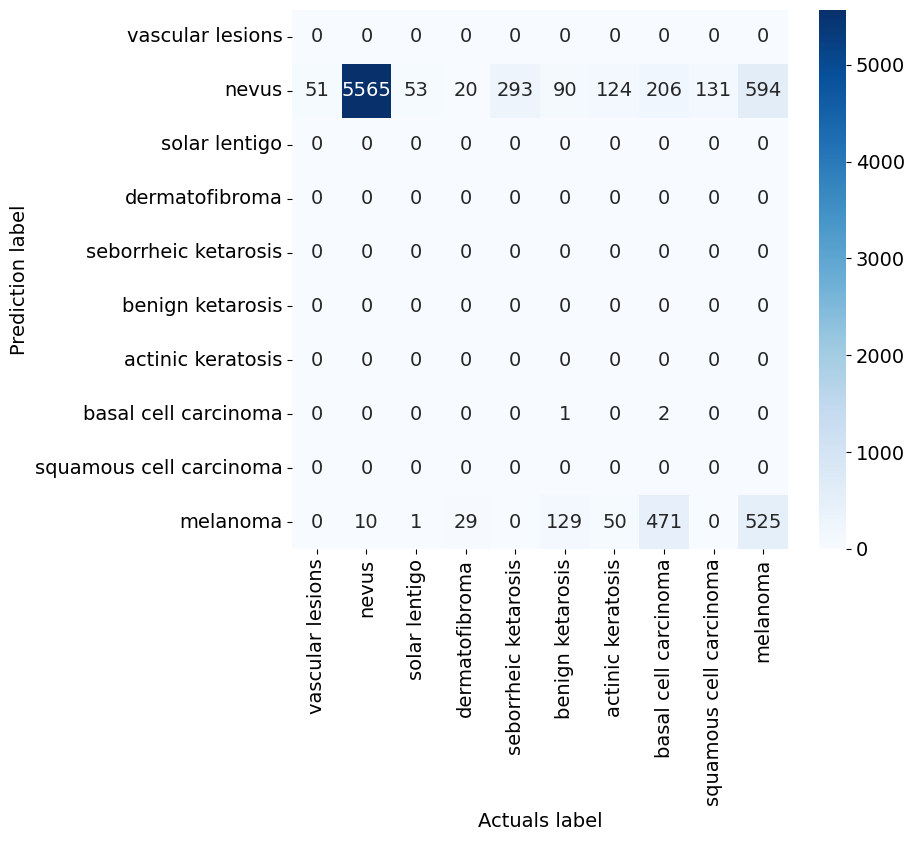

Sensitivity: 0.7300
Specificity: 0.9700
Precision: 0.7300
NPV: 0.9700
PPV: 0.7300
FNR: 0.2700
FPR: 0.0300
F1: 0.7300
Recall micro: 0.7300
Recall macro: 0.1470
Precision micro: 0.7300
Precision macro: 0.1880
F1 score micro: 0.7300
F1 score macro: 0.1332
Jaccard score micro: 0.5748
Jaccard score macro: 0.1073
Accuracy score: 0.7300
Matthews corrcoef: 0.3861
Specificity macro: 0.9340
Specificity micro: 0.9700
Specificity weighted: 0.6105
Specificity none - class vascular lesions (0): 1.0000
Specificity none - class nevus (1): 0.4361
Specificity none - class solar lentigo (2): 1.0000
Specificity none - class dermatofibroma (3): 1.0000
Specificity none - class seborrheic ketarosis (4): 1.0000
Specificity none - class benign ketarosis (5): 1.0000
Specificity none - class actinic keratosis (6): 1.0000
Specificity none - class basal cell carcinoma (7): 0.9999
Specificity none - class squamous cell carcinoma (8): 1.0000
Specificity none - class melanoma (9): 0.9045


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [49]:
actuals = []
predictions = []

device = torch.device('cpu')
ptq_model_model_quantized_CNN.to(device)

test_NN(ptq_model_model_quantized_CNN, testloader)

matrix = confusion_matrix(predictions, actuals)
df_matrix = pd.DataFrame(matrix, labels_cat2, labels_cat2)
plt.rcParams['font.size'] = '14'

plt.figure(figsize = (8,7))
sns.heatmap(df_matrix, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Actuals label")
plt.ylabel("Prediction label")
plt.show()

ptq_accuracy_CNN = test_metric()

In [50]:
class QuantizedMLP(nn.Module):
    def __init__(self, original_metadata_net):
        super().__init__()
        self.quant = QuantStub()
        self.dequant = DeQuantStub()
        self.metadata_net = original_metadata_net
        
    def forward(self, x):
        x = self.quant(x)
        x = self.metadata_net(x)
        x = self.dequant(x)
        return x

def quantize_MLP_separately(model, calibration_loader):
    visual_features_state = model.visual_features.state_dict().copy()
    visual_classifier_state = model.visual_classifier.state_dict().copy()
    combined_classifier_state = model.combined_classifier.state_dict().copy()
    
    quantized_metadata_net = QuantizedMLP(model.metadata_net)
    quantized_metadata_net = quantized_metadata_net.to(device)
    quantized_metadata_net.qconfig = get_default_qconfig('fbgemm')

    model_prepared = prepare(quantized_metadata_net, inplace=False)

    model_prepared.eval()
    with torch.no_grad():
        for i, data in enumerate(calibration_loader):
            images, metadata, label, name = data
            images, metadata = images.to(device), metadata.to(device)
            model_prepared(metadata)
            if i >= 50:
                break

    model_quantized_metadata_net = convert(model_prepared, inplace=False)

    model.metadata_net = model_quantized_metadata_net

    model.visual_features.load_state_dict(visual_features_state)
    model.visual_classifier.load_state_dict(visual_classifier_state)
    model.combined_classifier.load_state_dict(combined_classifier_state)

    return model

device = torch.device("cpu")
fp32_model = fp32_model.to(device)

ptq_model_MLP = Multimodal_NN(num_metadata_features, num_classes).to(device)
ptq_model_MLP.load_state_dict(fp32_model.state_dict())

ptq_model_model_quantized_MLP = quantize_MLP_separately(ptq_model_MLP, trainloader)
print(f"PTQ мультимодальная модель ptq_model_model_quantized_MLP на int_8 успешно сконвертирована!")

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


PTQ мультимодальная модель ptq_model_model_quantized_MLP на int_8 успешно сконвертирована!


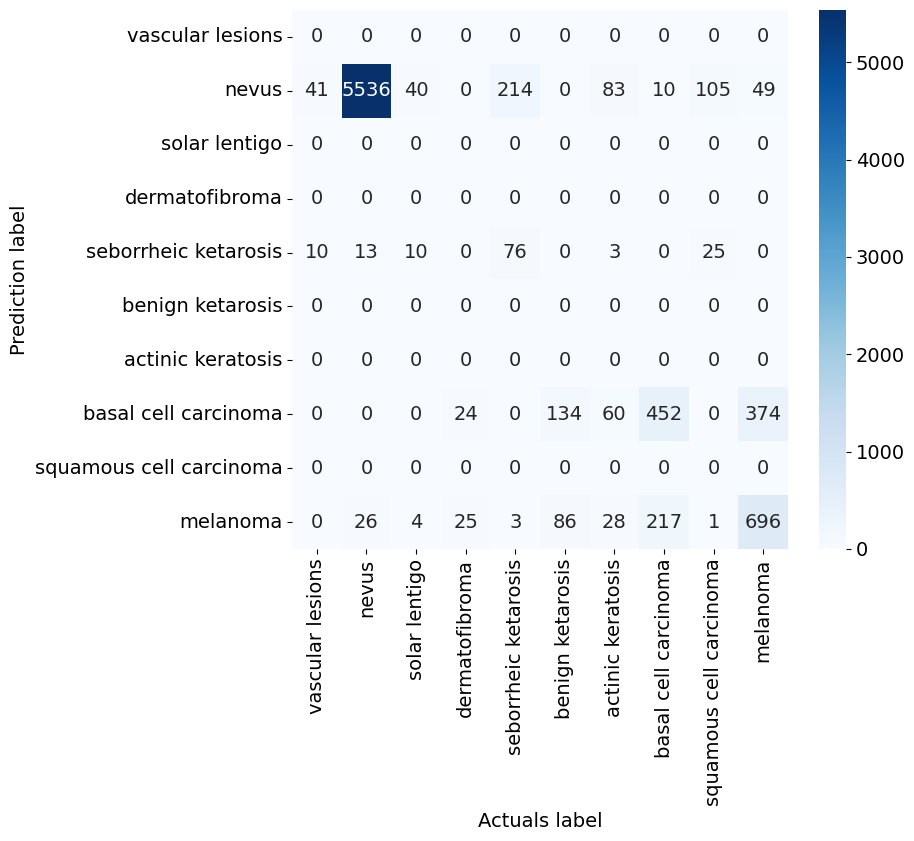

Sensitivity: 0.8101
Specificity: 0.9789
Precision: 0.8101
NPV: 0.9789
PPV: 0.8101
FNR: 0.1899
FPR: 0.0211
F1: 0.8101
Recall micro: 0.8101
Recall macro: 0.2540
Precision micro: 0.8101
Precision macro: 0.2539
F1 score micro: 0.8101
F1 score macro: 0.2460
Jaccard score micro: 0.6808
Jaccard score macro: 0.1937
Accuracy score: 0.8101
Matthews corrcoef: 0.6159
Specificity macro: 0.9666
Specificity micro: 0.9789
Specificity weighted: 0.8555
Specificity none - class vascular lesions (0): 1.0000
Specificity none - class nevus (1): 0.8043
Specificity none - class solar lentigo (2): 1.0000
Specificity none - class dermatofibroma (3): 1.0000
Specificity none - class seborrheic ketarosis (4): 0.9924
Specificity none - class benign ketarosis (5): 1.0000
Specificity none - class actinic keratosis (6): 1.0000
Specificity none - class basal cell carcinoma (7): 0.9228
Specificity none - class squamous cell carcinoma (8): 1.0000
Specificity none - class melanoma (9): 0.9460


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [52]:
actuals = []
predictions = []

device = torch.device("cpu")
test_NN(ptq_model_model_quantized_MLP, testloader)

matrix = confusion_matrix(predictions, actuals)
df_matrix = pd.DataFrame(matrix, labels_cat2, labels_cat2)
plt.rcParams['font.size'] = '14'

plt.figure(figsize = (8,7))
sns.heatmap(df_matrix, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Actuals label")
plt.ylabel("Prediction label")
plt.show()

ptq_accuracy_MLP = test_metric()

In [53]:
class QuantizedClassifiers(nn.Module):
    def __init__(self, original_visual_classifier, original_combined_classifier):
        super().__init__()
        self.quant = QuantStub()
        self.dequant = DeQuantStub()
        self.visual_classifier = original_visual_classifier
        self.combined_classifier = original_combined_classifier
        
    def forward(self, visual_features, metadata_features):
        visual_features = self.quant(visual_features)
        visual_out = self.visual_classifier(visual_features)
        visual_out = self.dequant(visual_out)
        
        combined_features = torch.cat((visual_out, metadata_features), dim=1)
        
        combined_features = self.quant(combined_features)
        output = self.combined_classifier(combined_features)
        output = self.dequant(output)
        
        return output

def quantize_classifiers_together(model, calibration_loader):
    visual_features_state = model.visual_features.state_dict().copy()
    metadata_net_state = model.metadata_net.state_dict().copy()
    
    quantized_classifiers = QuantizedClassifiers(
        model.visual_classifier, 
        model.combined_classifier
    )
    quantized_classifiers = quantized_classifiers.to(device)
    quantized_classifiers.qconfig = get_default_qconfig('fbgemm')

    model_prepared = prepare(quantized_classifiers, inplace=False)

    model_prepared.eval()
    with torch.no_grad():
        for i, data in enumerate(calibration_loader):
            images, metadata, label, name = data
            images, metadata = images.to(device), metadata.to(device)

            with torch.no_grad():
                visual_features = model.visual_features(images)
                visual_features = visual_features.reshape(visual_features.size(0), -1)

                metadata_features = model.metadata_net(metadata)

            model_prepared(visual_features, metadata_features)
            if i >= 50:
                break

    model_quantized_classifiers = convert(model_prepared, inplace=False)
    

    class Multimodal_With_QuantizedClassifiers(nn.Module):
        def __init__(self, visual_features, metadata_net, quantized_classifiers):
            super().__init__()
            self.visual_features = visual_features
            self.metadata_net = metadata_net
            self.quantized_classifiers = quantized_classifiers
            
        def forward(self, image, metadata):
            visual_features = self.visual_features(image)
            visual_features = visual_features.reshape(visual_features.size(0), -1)
            
            metadata_features = self.metadata_net(metadata)

            output = self.quantized_classifiers(visual_features, metadata_features)
            return output

    final_model = Multimodal_With_QuantizedClassifiers(
        model.visual_features,
        model.metadata_net, 
        model_quantized_classifiers
    )

    final_model.visual_features.load_state_dict(visual_features_state)
    final_model.metadata_net.load_state_dict(metadata_net_state)

    return final_model

device = torch.device("cpu")
fp32_model = fp32_model.to(device)

ptq_model_linear = Multimodal_NN(num_metadata_features, num_classes).to(device)
ptq_model_linear.load_state_dict(fp32_model.state_dict())

ptq_model_model_quantized_linear = quantize_classifiers_together(ptq_model_linear, trainloader)
print(f"PTQ мультимодальная модель ptq_model_model_quantized_linear на int_8 успешно сконвертирована!")

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


PTQ мультимодальная модель ptq_model_model_quantized_linear на int_8 успешно сконвертирована!


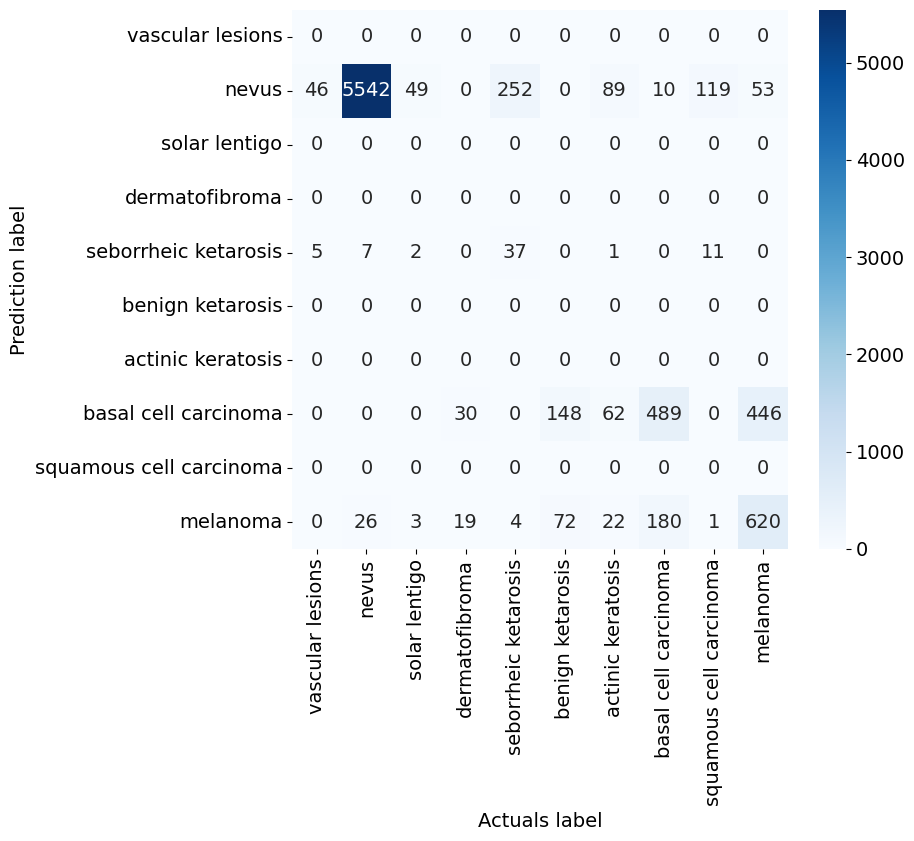

Sensitivity: 0.8014
Specificity: 0.9779
Precision: 0.8014
NPV: 0.9779
PPV: 0.8014
FNR: 0.1986
FPR: 0.0221
F1: 0.8014
Recall micro: 0.8014
Recall macro: 0.2395
Precision micro: 0.8014
Precision macro: 0.2558
F1 score micro: 0.8014
F1 score macro: 0.2280
Jaccard score micro: 0.6687
Jaccard score macro: 0.1798
Accuracy score: 0.8014
Matthews corrcoef: 0.5967
Specificity macro: 0.9639
Specificity micro: 0.9779
Specificity weighted: 0.8375
Specificity none - class vascular lesions (0): 1.0000
Specificity none - class nevus (1): 0.7769
Specificity none - class solar lentigo (2): 1.0000
Specificity none - class dermatofibroma (3): 1.0000
Specificity none - class seborrheic ketarosis (4): 0.9968
Specificity none - class benign ketarosis (5): 1.0000
Specificity none - class actinic keratosis (6): 1.0000
Specificity none - class basal cell carcinoma (7): 0.9105
Specificity none - class squamous cell carcinoma (8): 1.0000
Specificity none - class melanoma (9): 0.9547


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [55]:
actuals = []
predictions = []

device = torch.device("cpu")
test_NN(ptq_model_model_quantized_linear, testloader)

matrix = confusion_matrix(predictions, actuals)
df_matrix = pd.DataFrame(matrix, labels_cat2, labels_cat2)
plt.rcParams['font.size'] = '14'

plt.figure(figsize = (8,7))
sns.heatmap(df_matrix, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Actuals label")
plt.ylabel("Prediction label")
plt.show()

ptq_accuracy_linear = test_metric()

In [56]:
def quantize_completely_fx(model, calibration_loader, device="cpu", cal_batches=50):
    model.eval().to("cpu")

    example_inputs = (
        torch.randn(1, 3, 224, 224),
        torch.randn(1, num_metadata_features)
    )

    qconfig_dict = {"": get_default_qconfig("fbgemm")}

    prepared_model = prepare_fx(model, qconfig_dict, example_inputs)
    prepared_model.eval()
    
    print("Калибровка...")
    with torch.no_grad():
        for i, (images, metadata, _, _) in enumerate(calibration_loader):
            prepared_model(images.to("cpu"), metadata.to("cpu"))
            if i >= cal_batches:
                break

    quantized_model = convert_fx(prepared_model)
    quantized_model.to(device)
    
    return quantized_model

device = torch.device("cpu")
fp32_model = fp32_model.to(device)

ptq_model_full = Multimodal_NN(num_metadata_features, num_classes).to(device)
ptq_model_full.load_state_dict(fp32_model.state_dict())

ptq_model_model_quantized_full = quantize_completely_fx(ptq_model_full, trainloader, device="cpu")

print("Полностью квантованная мультимодальная модель (FX PTQ, int8) успешно сконвертирована!")

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\quantize_fx.py:146: FutureWarning: Passing a QConfig dictionary to prepare is deprecated and will not be supported in a future version. Please pass in a QConfigMapping instead.
  prepared = prepare(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\fx\utils.py:923: UserWarning: QConfig must specify a FixedQParamsObserver or a FixedQParamsFakeQuantize for fixed qparams ops, ignoring QConfig(activation=functools.partial(<class 'torch.ao.quantization.observer.HistogramObserver'>, reduce_range=True){'factory_kwargs': <function _add_module_to_qconfig_obs_ctr.<locals>.get_factory_kwargs_based_on_modul

Калибровка...


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


Полностью квантованная мультимодальная модель (FX PTQ, int8) успешно сконвертирована!


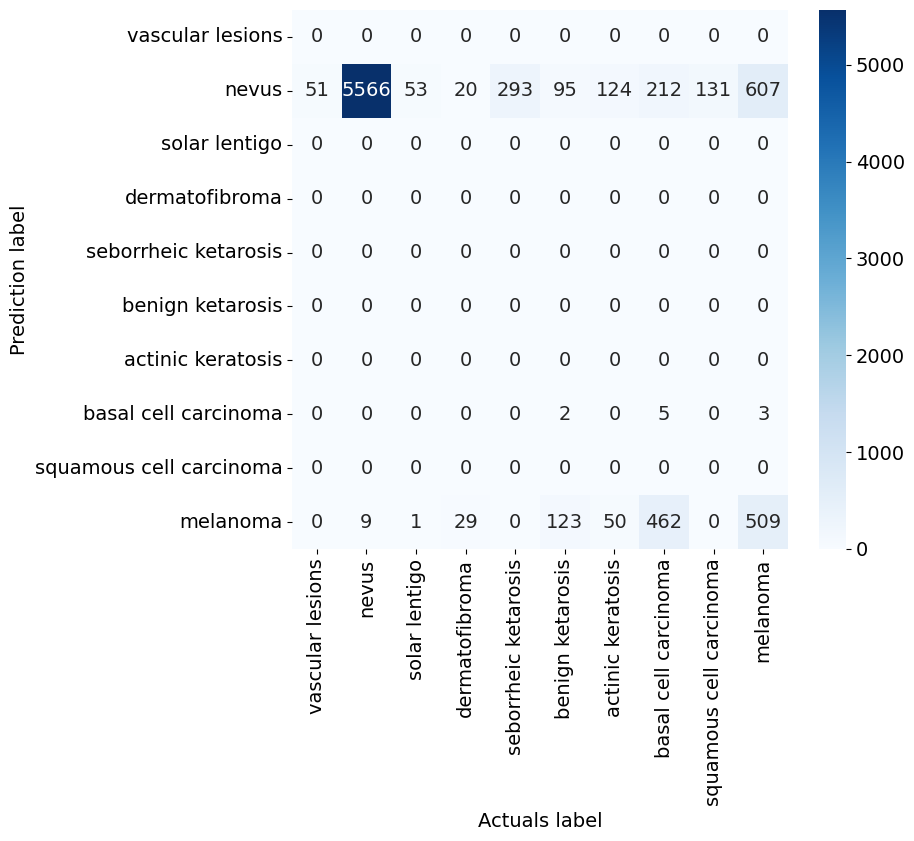

Sensitivity: 0.7286
Specificity: 0.9698
Precision: 0.7286
NPV: 0.9698
PPV: 0.7286
FNR: 0.2714
FPR: 0.0302
F1: 0.7286
Recall micro: 0.7286
Recall macro: 0.1461
Precision micro: 0.7286
Precision macro: 0.1709
F1 score micro: 0.7286
F1 score macro: 0.1331
Jaccard score micro: 0.5730
Jaccard score macro: 0.1068
Accuracy score: 0.7286
Matthews corrcoef: 0.3810
Specificity macro: 0.9334
Specificity micro: 0.9698
Specificity weighted: 0.6049
Specificity none - class vascular lesions (0): 1.0000
Specificity none - class nevus (1): 0.4274
Specificity none - class solar lentigo (2): 1.0000
Specificity none - class dermatofibroma (3): 1.0000
Specificity none - class seborrheic ketarosis (4): 1.0000
Specificity none - class benign ketarosis (5): 1.0000
Specificity none - class actinic keratosis (6): 1.0000
Specificity none - class basal cell carcinoma (7): 0.9993
Specificity none - class squamous cell carcinoma (8): 1.0000
Specificity none - class melanoma (9): 0.9067


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [58]:
actuals = []
predictions = []

device = torch.device("cpu")
test_NN(ptq_model_model_quantized_full, testloader)

matrix = confusion_matrix(predictions, actuals)
df_matrix = pd.DataFrame(matrix, labels_cat2, labels_cat2)
plt.rcParams['font.size'] = '14'

plt.figure(figsize = (8,7))
sns.heatmap(df_matrix, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Actuals label")
plt.ylabel("Prediction label")
plt.show()

ptq_accuracy_full = test_metric()

In [70]:
from torch.ao.quantization import get_default_qat_qconfig
from torch.ao.quantization import prepare_qat
from torch.ao.quantization import convert

def QAT_quantize_CNN_separately(model, device="cpu"):

    visual_classifier_state = model.visual_classifier.state_dict().copy()
    metadata_net_state = model.metadata_net.state_dict().copy()
    combined_classifier_state = model.combined_classifier.state_dict().copy()
    
    vf = model.visual_features.to("cpu")
    vf.train()
    
    vf.qconfig = get_default_qat_qconfig('fbgemm')  # Устанавливаем qconfig
    prepared = prepare_qat(vf, inplace=False)

    model.visual_features = prepared

    model.visual_classifier.load_state_dict(visual_classifier_state)
    model.metadata_net.load_state_dict(metadata_net_state)
    model.combined_classifier.load_state_dict(combined_classifier_state)
    
    return model

device = torch.device("cpu")
fp32_model = fp32_model.to(device)

qat_model_CNN = Multimodal_NN(num_metadata_features, num_classes).to(device)
qat_model_CNN.load_state_dict(fp32_model.state_dict())

qat_model_CNN = QAT_quantize_CNN_separately(qat_model_CNN)

print("Начало QAT с предобученными весами...")
    
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(qat_model_CNN.parameters(), lr=0.001, momentum=0.9)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode = 'min', factor = 0.1, patience = 3)
    
num_epochs = 5
    
train_losses = []
train_counter = []
train_acc = []
    
test_losses = []
test_counter = [i*len_trainset for i in range(num_epochs)]
test_acc = []
    
device = torch.device("cpu")
qat_model_CNN  = train_and_evaluate(qat_model_CNN, trainloader, valloader, criterion, optimizer, len_trainset, len_valset, num_epochs, 'qat_model_CNN')

device = torch.device("cpu")

qat_model_CNN.eval()

qat_model_CNN.visual_features = convert_fx(qat_model_CNN.visual_features)
qat_model_CNN = qat_model_CNN.to(device)

print(f"QAT мультимодальная модель qat_model_CNN на int_8 успешно сконвертирована!")

Начало QAT с предобученными весами...
________________________________________________________________________________________________________________________
Эпоха 1/5

Тренировочная эпоха: 1 [0/25035 (0%)]		 | Ошибка: 1.6469	 | Точность распознавания: 71.88%
Тренировочная эпоха: 1 [6400/25035 (26%)]		 | Ошибка: 0.7443	 | Точность распознавания: 73.58%
Тренировочная эпоха: 1 [12800/25035 (51%)]		 | Ошибка: 0.5522	 | Точность распознавания: 74.96%
Тренировочная эпоха: 1 [19200/25035 (77%)]		 | Ошибка: 0.6976	 | Точность распознавания: 75.96%

   Тренировочная ошибка: 0.7231 Точность: 19106/25035 (76.32%)
        Время обучения: 00:07:51

   Валидационная ошибка: 0.8604 Точность: 6179/8345 (74.04%)
        Время тестирования: 00:01:01

Лучшая валидационная точность: 0.7404
________________________________________________________________________________________________________________________
Эпоха 2/5

Тренировочная эпоха: 2 [0/25035 (0%)]		 | Ошибка: 0.6240	 | Точность распознавания: 7

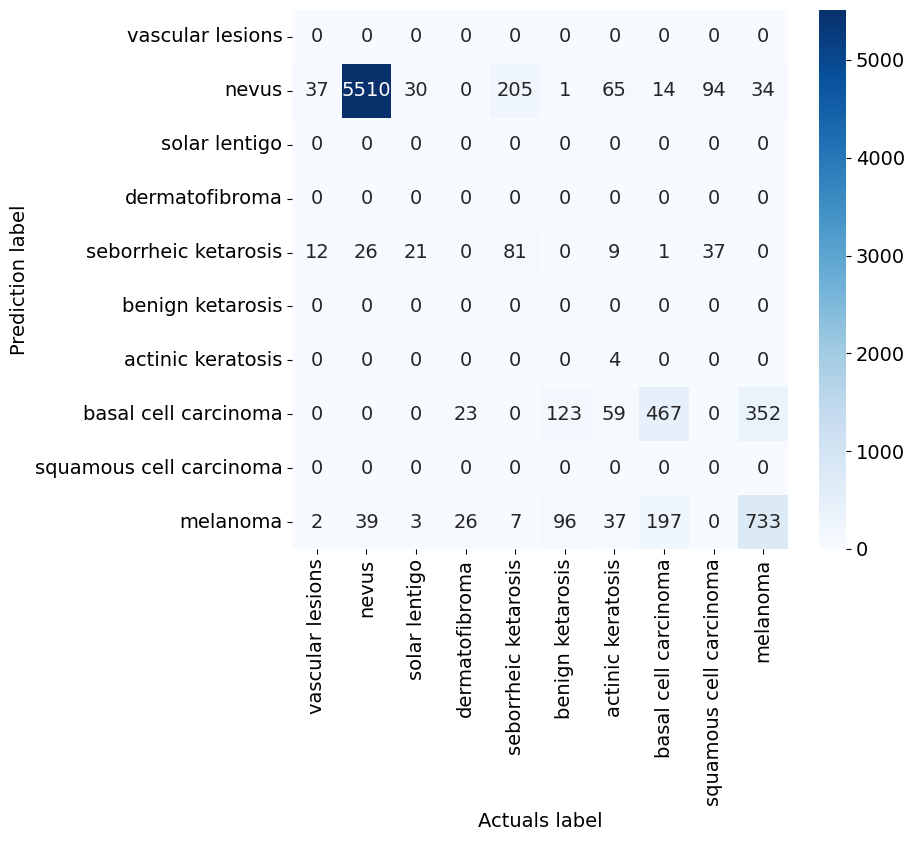

Sensitivity: 0.8143
Specificity: 0.9794
Precision: 0.8143
NPV: 0.9794
PPV: 0.8143
FNR: 0.1857
FPR: 0.0206
F1: 0.8143
Recall micro: 0.8143
Recall macro: 0.2631
Precision micro: 0.8143
Precision macro: 0.3452
F1 score micro: 0.8143
F1 score macro: 0.2533
Jaccard score micro: 0.6867
Jaccard score macro: 0.1994
Accuracy score: 0.8143
Matthews corrcoef: 0.6276
Specificity macro: 0.9685
Specificity micro: 0.9794
Specificity weighted: 0.8703
Specificity none - class vascular lesions (0): 1.0000
Specificity none - class nevus (1): 0.8267
Specificity none - class solar lentigo (2): 1.0000
Specificity none - class dermatofibroma (3): 1.0000
Specificity none - class seborrheic ketarosis (4): 0.9868
Specificity none - class benign ketarosis (5): 1.0000
Specificity none - class actinic keratosis (6): 1.0000
Specificity none - class basal cell carcinoma (7): 0.9273
Specificity none - class squamous cell carcinoma (8): 1.0000
Specificity none - class melanoma (9): 0.9437


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [66]:
actuals = []
predictions = []

device = torch.device("cpu")
test_NN(qat_model_classifier, testloader)

matrix = confusion_matrix(predictions, actuals)
df_matrix = pd.DataFrame(matrix, labels_cat2, labels_cat2)
plt.rcParams['font.size'] = '14'

plt.figure(figsize = (8,7))
sns.heatmap(df_matrix, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Actuals label")
plt.ylabel("Prediction label")
plt.show()

qat_accuracy_classifier = test_metric()

In [67]:
class QuantizedMultimodal_QAT(nn.Module):
    def __init__(self, original_model):
        super().__init__()
        self.quant = QuantStub()
        self.dequant = DeQuantStub()

        self.visual_features = original_model.visual_features
        self.visual_classifier = original_model.visual_classifier
        self.metadata_net = original_model.metadata_net
        self.combined_classifier = original_model.combined_classifier
        
    def forward(self, image, metadata):
        image = self.quant(image)
        metadata = self.quant(metadata)

        visual_feat = self.visual_features(image)
        visual_feat = visual_feat.view(visual_feat.size(0), -1)
        visual_out = self.visual_classifier(visual_feat)
        
        metadata_out = self.metadata_net(metadata)

        visual_out = self.dequant(visual_out)
        metadata_out = self.dequant(metadata_out)
        
        combined = torch.cat((visual_out, metadata_out), dim=1)

        combined = self.quant(combined)
        output = self.combined_classifier(combined)
        output = self.dequant(output)
        
        return output

def QAT_quantize_completely_simple(model):
    
    quant_model = QuantizedMultimodal_QAT(model)
    quant_model = quant_model.to(device)

    quant_model.qconfig = torch.quantization.get_default_qat_qconfig('fbgemm')

    model_prepared = prepare_qat(quant_model, inplace=False)
    
    return model_prepared

device = torch.device("cpu")
fp32_model = fp32_model.to(device)

qat_model_full = Multimodal_NN(num_metadata_features, num_classes).to(device)
qat_model_full.load_state_dict(fp32_model.state_dict())

qat_model_full = QAT_quantize_completely_simple(qat_model_full)

print("Начало QAT с предобученными весами...")
    
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(qat_model_full.parameters(), lr=0.001, momentum=0.9)
    
num_epochs = 5
    
train_losses = []
train_counter = []
train_acc = []
    
test_losses = []
test_counter = [i*len_trainset for i in range(num_epochs)]
test_acc = []
    
device = torch.device("cuda")
qat_model_full  = train_and_evaluate(qat_model_full, trainloader, valloader, criterion, optimizer, len_trainset, len_valset, num_epochs, 'qat_model_full')

device = torch.device("cpu")
qat_model_full.eval()
qat_model_full  = qat_model_full.to(device)
qat_model_full = convert(qat_model_full, inplace=False)

print(f"QAT мультимодальная модель qat_model_full на int_8 успешно сконвертирована!")

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torch\ao\quantization\observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


Начало QAT с предобученными весами...
________________________________________________________________________________________________________________________
Эпоха 1/5

Тренировочная эпоха: 1 [0/25035 (0%)]		 | Ошибка: 0.7355	 | Точность распознавания: 78.12%
Тренировочная эпоха: 1 [6400/25035 (26%)]		 | Ошибка: 0.7454	 | Точность распознавания: 75.15%
Тренировочная эпоха: 1 [12800/25035 (51%)]		 | Ошибка: 0.6190	 | Точность распознавания: 75.81%
Тренировочная эпоха: 1 [19200/25035 (77%)]		 | Ошибка: 0.7405	 | Точность распознавания: 76.58%

   Тренировочная ошибка: 0.6898 Точность: 19279/25035 (77.01%)
        Время обучения: 00:00:37

   Валидационная ошибка: 0.8103 Точность: 6267/8345 (75.10%)
        Время тестирования: 00:00:07

Лучшая валидационная точность: 0.7510
________________________________________________________________________________________________________________________
Эпоха 2/5

Тренировочная эпоха: 2 [0/25035 (0%)]		 | Ошибка: 0.5962	 | Точность распознавания: 7

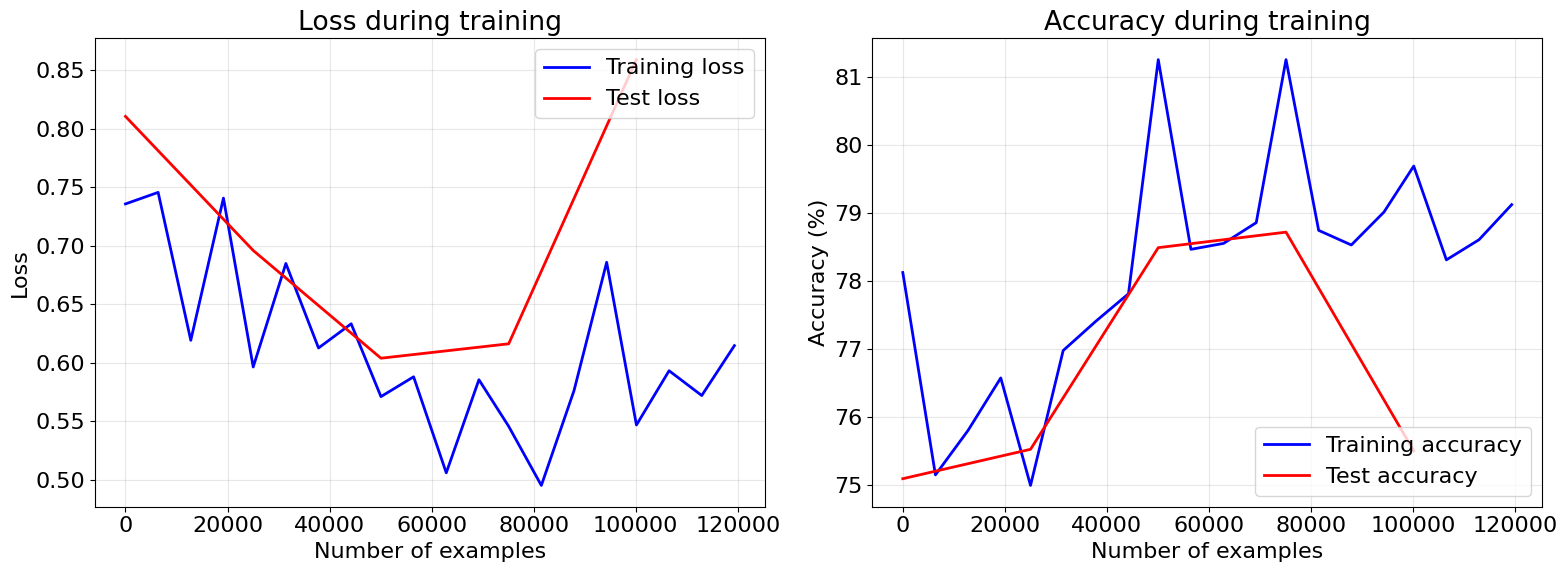

In [68]:
plt.figure(figsize=(16, 6))
plt.rcParams['font.size'] = '16'

# Первый график - Loss
plt.subplot(1, 2, 1)  # 1 строка, 2 столбца, 1-й график
plt.plot(train_counter, train_losses, color='blue', linewidth=2)
plt.plot(test_counter, test_losses, color='red', linewidth=2)
plt.legend(['Training loss', 'Test loss'], loc='upper right')
plt.xlabel('Number of examples')
plt.ylabel('Loss')
plt.title('Loss during training')
plt.grid(True, alpha=0.3)

# Второй график - Accuracy
plt.subplot(1, 2, 2)  # 1 строка, 2 столбца, 2-й график
plt.plot(train_counter, train_acc, color='blue', linewidth=2)
plt.plot(test_counter, test_acc, color='red', linewidth=2)
plt.legend(['Training accuracy', 'Test accuracy'], loc='lower right')
plt.xlabel('Number of examples')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy during training')
plt.grid(True, alpha=0.3)

plt.tight_layout()  # Чтобы графики не перекрывались
plt.show()

C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\shufflenetv2.py:97: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  out = torch.cat((self.branch1(x), self.branch2(x)), dim=1)
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\shufflenetv2.py:95: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  out = torch.cat((x1, self.branch2(x2)), dim=1)
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\shufflenetv2.py:97: UserWarning: All inputs of this cat operator must sha

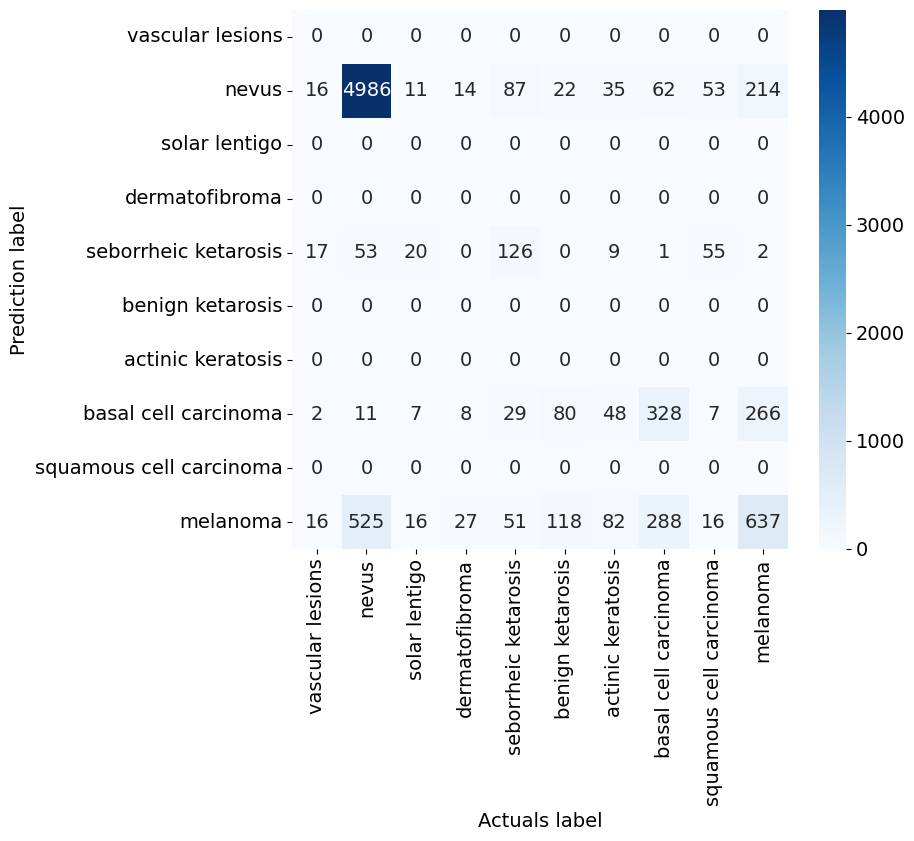

Sensitivity: 0.7282
Specificity: 0.9698
Precision: 0.7282
NPV: 0.9698
PPV: 0.7282
FNR: 0.2718
FPR: 0.0302
F1: 0.7282
Recall micro: 0.7282
Recall macro: 0.2377
Precision micro: 0.7282
Precision macro: 0.2128
F1 score micro: 0.7282
F1 score macro: 0.2226
Jaccard score micro: 0.5726
Jaccard score macro: 0.1669
Accuracy score: 0.7282
Matthews corrcoef: 0.4834
Specificity macro: 0.9578
Specificity micro: 0.9698
Specificity weighted: 0.8494
Specificity none - class vascular lesions (0): 1.0000
Specificity none - class nevus (1): 0.8144
Specificity none - class solar lentigo (2): 1.0000
Specificity none - class dermatofibroma (3): 1.0000
Specificity none - class seborrheic ketarosis (4): 0.9805
Specificity none - class benign ketarosis (5): 1.0000
Specificity none - class actinic keratosis (6): 1.0000
Specificity none - class basal cell carcinoma (7): 0.9403
Specificity none - class squamous cell carcinoma (8): 1.0000
Specificity none - class melanoma (9): 0.8424


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [70]:
actuals = []
predictions = []

device = torch.device("cpu")
test_NN(qat_model_full, testloader)

matrix = confusion_matrix(predictions, actuals)
df_matrix = pd.DataFrame(matrix, labels_cat2, labels_cat2)
plt.rcParams['font.size'] = '14'

plt.figure(figsize = (8,7))
sns.heatmap(df_matrix, annot=True, fmt="d", cmap='Blues')
plt.xlabel("Actuals label")
plt.ylabel("Prediction label")
plt.show()

qat_accuracy_full = test_metric()

In [76]:
def print_statistics(accuracy_data, size_data, speed_data):
    """Выводит статистику по всем моделям"""
    
    print("_" * 80)
    print("📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ МОДЕЛЕЙ")
    print("_" * 80)
    
    # Лучшие модели по каждому показателю
    best_accuracy = max(accuracy_data.items(), key=lambda x: x[1])
    best_compression = max(size_data.items(), key=lambda x: size_data['FP32'] / x[1])
    best_speed = max(speed_data.items(), key=lambda x: x[1])
    
    print(f"🏆 Лучшая точность: {best_accuracy[0]} - {best_accuracy[1]:.2f}%")
    print(f"🏆 Лучшее сжатие: {best_compression[0]} - {size_data['FP32']/best_compression[1]:.2f}x")
    print(f"🏆 Лучшая скорость: {best_speed[0]} - {best_speed[1]:.2f}x")
    print()
    
    # Сравнение PTQ vs QAT
    ptq_models = {k: v for k, v in accuracy_data.items() if k.startswith('PTQ')}
    qat_models = {k: v for k, v in accuracy_data.items() if k.startswith('QAT')}
    
    if ptq_models and qat_models:
        avg_ptq_accuracy = sum(ptq_models.values()) / len(ptq_models)
        avg_qat_accuracy = sum(qat_models.values()) / len(qat_models)
        
        print("📈 СРЕДНИЕ ПОКАЗАТЕЛИ:")
        print(f"  PTQ модели: {avg_ptq_accuracy:.2f}% точность")
        print(f"  QAT модели: {avg_qat_accuracy:.2f}% точность")
        
        if avg_qat_accuracy > avg_ptq_accuracy:
            print(f"  ✅ QAT показывает лучшую среднюю точность на {avg_qat_accuracy - avg_ptq_accuracy:.2f}%")
        else:
            print(f"  ⚠️ PTQ показывает лучшую среднюю точность на {avg_ptq_accuracy - avg_qat_accuracy:.2f}%")
    
    print("\n🎯 РЕКОМЕНДАЦИИ:")
    
    # Рекомендации на основе данных
    if accuracy_data.get('PTQ_full', 0) > 95 and speed_data.get('PTQ_full', 0) > 1.5:
        print("  ✅ PTQ Full - оптимальный выбор: высокая точность и скорость")
    elif accuracy_data.get('QAT_full', 0) > accuracy_data.get('PTQ_full', 0):
        print("  ✅ QAT Full - лучшая точность при полном квантовании")
    else:
        print("  ✅ PTQ Full - лучший баланс точности и производительности")
    
    if size_data['FP32'] / size_data.get('PTQ_full', 1) > 3.5:
        print("  ✅ Отличное сжатие моделей (более 3.5x)")

🎯 КОМПЛЕКСНЫЙ ОТЧЕТ ПО ВСЕМ МОДЕЛЯМ
____________________________________________________________
Точность FP32: 81.31%
____________________________________________________________
Точность PTQ_CNN: 76.30%
Точность PTQ_MLP: 81.31%
Точность PTQ_classif: 80.71%
Точность PTQ_full: 72.82%
____________________________________________________________
Точность QAT_CNN: 78.08%
Точность QAT_MLP: 81.87%
Точность QAT_classif: 81.43%
Точность QAT_full: 76.79%
____________________________________________________________
🚀 ЗАПУСК БЕНЧМАРКОВ ВСЕХ МОДЕЛЕЙ
______________________________________________________________________
🔵 Бенчмарк FP32 оригинальной модели...

🎯 PTQ МОДЕЛИ:
--------------------------------------------------
Бенчмарк PTQ AlexNet...


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\shufflenetv2.py:97: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  out = torch.cat((self.branch1(x), self.branch2(x)), dim=1)
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\shufflenetv2.py:95: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  out = torch.cat((x1, self.branch2(x2)), dim=1)
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\shufflenetv2.py:97: UserWarning: All inputs of this cat operator must sha

Бенчмарк PTQ MLP...
Бенчмарк PTQ Classifiers...
Бенчмарк PTQ Full...


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\shufflenetv2.py:97: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  out = torch.cat((self.branch1(x), self.branch2(x)), dim=1)
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\shufflenetv2.py:95: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  out = torch.cat((x1, self.branch2(x2)), dim=1)
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\shufflenetv2.py:97: UserWarning: All inputs of this cat operator must sha


🎯 QAT МОДЕЛИ:
--------------------------------------------------
Бенчмарк QAT AlexNet...


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\shufflenetv2.py:97: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  out = torch.cat((self.branch1(x), self.branch2(x)), dim=1)
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\shufflenetv2.py:95: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  out = torch.cat((x1, self.branch2(x2)), dim=1)
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\shufflenetv2.py:97: UserWarning: All inputs of this cat operator must sha

Бенчмарк QAT MLP...
Бенчмарк QAT Classifiers...
Бенчмарк QAT Full...


C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\shufflenetv2.py:97: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  out = torch.cat((self.branch1(x), self.branch2(x)), dim=1)
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\shufflenetv2.py:95: UserWarning: All inputs of this cat operator must share the same quantization parameters. Otherwise large numerical inaccuracies may occur. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\quantized\cpu\TensorShape.cpp:168.)
  out = torch.cat((x1, self.branch2(x2)), dim=1)
C:\Users\Ulyana\anaconda3\envs\NN_3_11_11\Lib\site-packages\torchvision\models\shufflenetv2.py:97: UserWarning: All inputs of this cat operator must sha


________________________________________________________________________________
📊 РЕЗУЛЬТАТЫ СКОРОСТИ (CPU)
________________________________________________________________________________
Модель                    Время батча  Ускорение  Статус         
--------------------------------------------------------------------------------
FP32 Original               0.2218s    -             Базовый        
PTQ Alexnet                 0.3895s       0.57x    ⚠️ НОРМА       
PTQ Mlp                     0.1942s       1.14x    ✅ ХОРОШО       
PTQ Classifiers             0.2000s       1.11x    ✅ ХОРОШО       
PTQ Full                    0.3896s       0.57x    ⚠️ НОРМА       
QAT Alexnet                 0.3896s       0.57x    ⚠️ НОРМА       
QAT Mlp                     0.1946s       1.14x    ✅ ХОРОШО       
QAT Classifiers             0.1964s       1.13x    ✅ ХОРОШО       
QAT Full                    0.3918s       0.57x    ⚠️ НОРМА       

🏆 Лучшее PTQ ускорение: mlp - 1.14x
🏆 Лучшее QAT ускорен

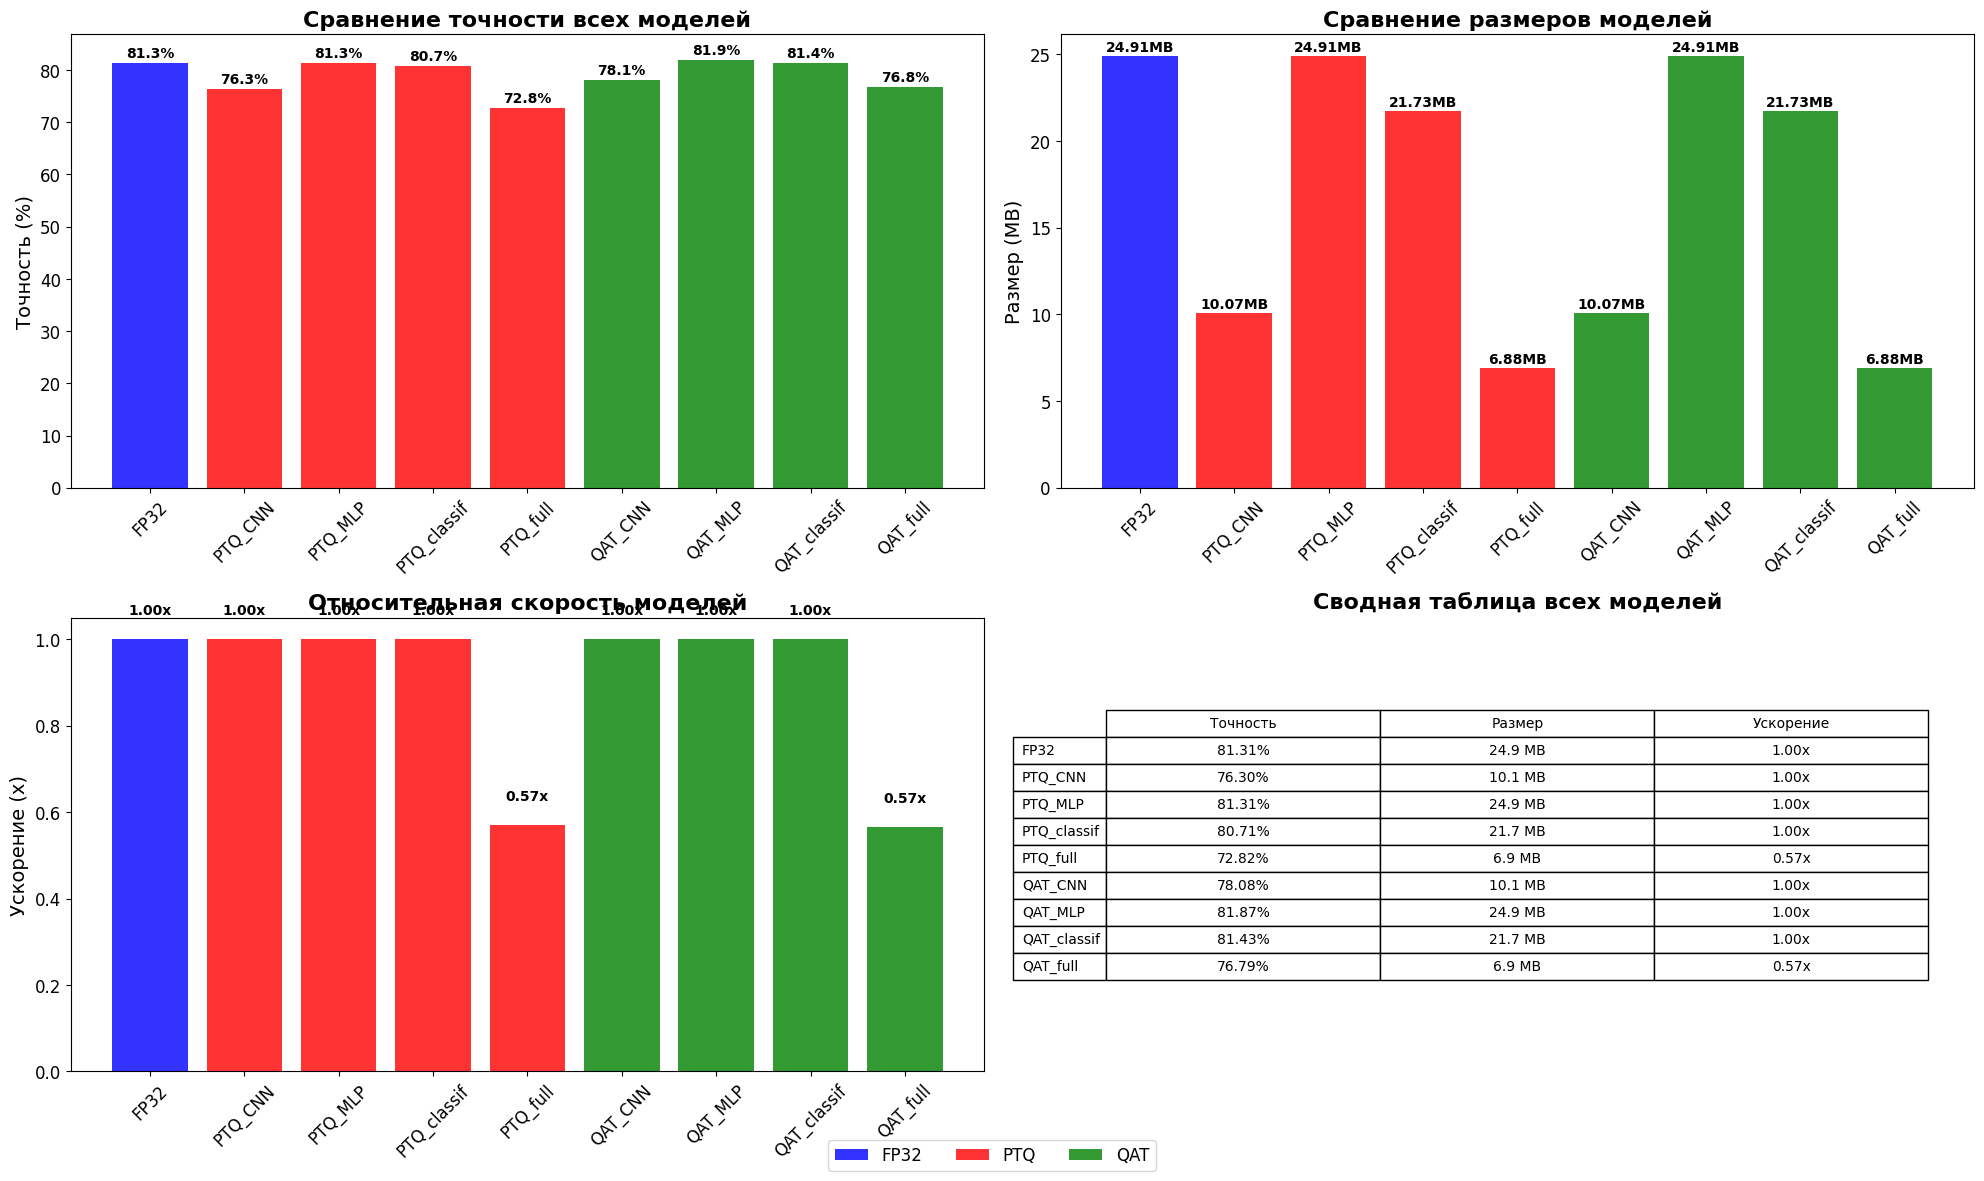

________________________________________________________________________________
📊 СТАТИСТИЧЕСКИЙ АНАЛИЗ МОДЕЛЕЙ
________________________________________________________________________________
🏆 Лучшая точность: QAT_MLP - 81.87%
🏆 Лучшее сжатие: PTQ_full - 3.62x
🏆 Лучшая скорость: PTQ_mlp - 1.14x

📈 СРЕДНИЕ ПОКАЗАТЕЛИ:
  PTQ модели: 77.78% точность
  QAT модели: 79.54% точность
  ✅ QAT показывает лучшую среднюю точность на 1.76%

🎯 РЕКОМЕНДАЦИИ:
  ✅ QAT Full - лучшая точность при полном квантовании
  ✅ Отличное сжатие моделей (более 3.5x)


In [79]:
# Запускаем полный отчет
print("🎯 КОМПЛЕКСНЫЙ ОТЧЕТ ПО ВСЕМ МОДЕЛЯМ")
print("_" * 60)

# Выводим исходные данные точности
print(f"Точность FP32: {fp32_final_acc:.2f}%")
print("_" * 60)

print(f"Точность PTQ_CNN: {ptq_accuracy_CNN:.2f}%")
print(f"Точность PTQ_MLP: {ptq_accuracy_MLP:.2f}%")
print(f"Точность PTQ_classif: {ptq_accuracy_linear:.2f}%")
print(f"Точность PTQ_full: {ptq_accuracy_full_1:.2f}%")
print("_" * 60)

print(f"Точность QAT_CNN: {qat_accuracy_CNN:.2f}%")
print(f"Точность QAT_MLP: {qat_accuracy_MLP:.2f}%")
print(f"Точность QAT_classif: {qat_accuracy_classifier:.2f}%")
print(f"Точность QAT_full: {qat_accuracy_full:.2f}%")
print("_" * 60)

# Создаем визуализацию
accuracy_data, size_data, speed_data = create_comprehensive_report()